# 04 — Final charts for the Phase 1 report

## 1. Purpose
Produce the publication figures for the 5-page PDF. **This notebook does not recompute any analysis**: every
number comes from `outputs/results/` written by Notebooks 01–03, so a figure can never disagree with the
validated results. Figures whose inputs are missing are skipped with a message.

**Visual system.** Source Sans 3 throughout; one colour rule everywhere: **orange = more exposure than
expected, blue = less, grey = context**. Figure widths match the PDF layout (full width 7.3 in, half 3.5 in).

## 2. Setup

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator, NullFormatter
from src import data as D, style as S

OUT = D.output_dir(); RES = OUT / "results"; FIG = OUT / "figures" / "final"
FIG.mkdir(parents=True, exist_ok=True)
S.apply()
FULL, HALF = 7.3, 3.55
MIN_ARTICLES = 50       # categories below this are excluded from headline charts (Notebook 01)
LBL = S.category_label

def have(*names):
    missing = [n for n in names if not (RES / n).exists()]
    if missing:
        print("SKIP — missing results:", missing)
    return not missing

def pct(x, d=0):
    return f"{x * 100:.{d}f}%"
print("results dir:", RES)

results dir: /home/user/information-diversity/outputs/results


## 3. Validation of inputs

In [2]:
for n in ["category_metrics.csv", "concentration_metrics.csv", "article_exposure.csv", "headline_metrics.json",
          "narrowing_alignment_by_quintile.csv", "narrowing_alignment_by_category.csv", "diversity_metrics.csv",
          "narrowing_hist2d.csv", "recommender_frontier.csv", "recommender_metrics.csv", "recommender_mmr_selected.csv"]:
    print(f"{'OK ' if (RES / n).exists() else '-- '} {n}")
if have("category_metrics.csv"):
    cat = pd.read_csv(RES / "category_metrics.csv", index_col=0)
    main = cat[cat["n_articles"] >= MIN_ARTICLES].copy()
    assert abs(cat["catalogue_share"].sum() - 1) < 1e-9 and abs(cat["exposure_share"].sum() - 1) < 1e-9
    print(f"{len(main)} categories with ≥{MIN_ARTICLES} articles; excluded:", sorted(set(cat.index) - set(main.index)))

OK  category_metrics.csv
OK  concentration_metrics.csv
OK  article_exposure.csv
OK  headline_metrics.json
--  narrowing_alignment_by_quintile.csv
--  narrowing_alignment_by_category.csv
--  diversity_metrics.csv
--  narrowing_hist2d.csv
--  recommender_frontier.csv
--  recommender_metrics.csv
--  recommender_mmr_selected.csv
14 categories with ≥50 articles; excluded: ['games', 'kids', 'middleeast', 'northamerica']


## 4. Figure 1 — Catalogue → exposure → clicks (slopegraph)

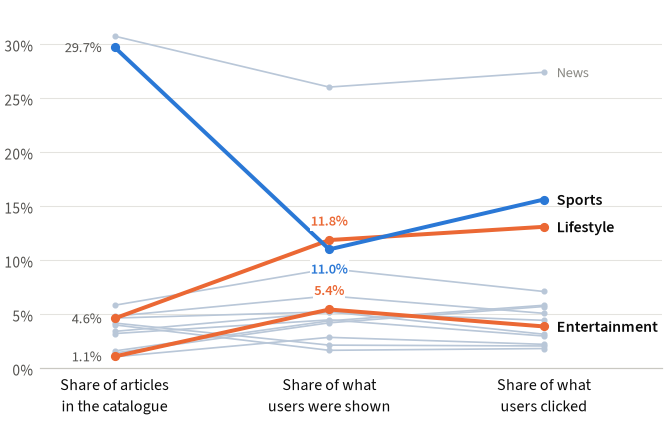

In [3]:
if have("category_metrics.csv"):
    d = main.copy()
    d["gain"] = d["exposure_share"] - d["catalogue_share"]
    hl = {d["amplification"].idxmax(): S.ORANGE, d["gain"].idxmax(): S.ORANGE, d["amplification"].idxmin(): S.BLUE,
          d["gain"].idxmin(): S.BLUE}
    fig, ax = plt.subplots(figsize=(FULL, 4.3))
    xs = [0, 1, 2]
    cols = ["catalogue_share", "exposure_share", "click_share"]
    for c, r in d.iterrows():
        y = [r[k] * 100 for k in cols]
        color = hl.get(c, S.BASE)
        ax.plot(xs, y, color=color, lw=2.6 if c in hl else 1.1, marker="o", ms=5 if c in hl else 3,
                zorder=3 if c in hl else 2, solid_capstyle="round")
        if c in hl:
            ax.text(2.06, y[2], f"{LBL(c)}", va="center", ha="left", fontsize=10.5, color=S.INK, fontweight="semibold")
            ax.text(-0.06, y[0], pct(r["catalogue_share"], 1), va="center", ha="right", fontsize=9.5, color=S.INK2)
            above = color == S.ORANGE
            ax.text(1, y[1] + (0.9 if above else -0.9), pct(r["exposure_share"], 1), va="bottom" if above else "top",
                    ha="center", fontsize=9.5, color=color, fontweight="semibold",
                    bbox=dict(fc="white", ec="none", pad=0.6), zorder=5)
    others = [c for c in d.index if c not in hl]
    top_other = d.loc[others, "click_share"].idxmax()
    ax.text(2.06, d.loc[top_other, "click_share"] * 100, LBL(top_other), va="center", fontsize=9.5, color=S.MUTED)
    ax.set_xticks(xs, ["Share of articles\nin the catalogue", "Share of what\nusers were shown", "Share of what\nusers clicked"])
    ax.tick_params(axis="x", labelsize=10.5, colors=S.INK)
    ax.set_xlim(-0.35, 2.55); ax.set_ylim(0, d[cols].to_numpy().max() * 100 + 3)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.grid(axis="x", visible=False); ax.spines["left"].set_visible(False)
    S.save(fig, FIG / "fig1_slopegraph"); plt.show()

## 5. Figure 2 — Exposure amplification by category

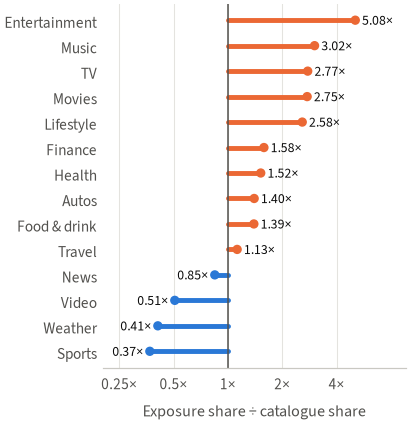

In [4]:
if have("category_metrics.csv"):
    d = main.sort_values("amplification")
    fig, ax = plt.subplots(figsize=(HALF, 4.3))
    y = np.arange(len(d))
    colors = [S.ORANGE if a > 1 else S.BLUE for a in d["amplification"]]
    ax.hlines(y, 1, d["amplification"], color=colors, lw=3.2, capstyle="round")
    ax.scatter(d["amplification"], y, color=colors, s=26, zorder=3)
    ax.axvline(1, color=S.INK2, lw=1)
    for yi, a in zip(y, d["amplification"]):
        ax.text(a * (1.09 if a > 1 else 0.92), yi, f"{a:.2f}×", va="center", ha="left" if a > 1 else "right",
                fontsize=9, color=S.INK)
    ax.set_xscale("log"); ax.set_xlim(d["amplification"].min() * 0.55, d["amplification"].max() * 1.9)
    ax.xaxis.set_major_locator(FixedLocator([0.25, 0.5, 1, 2, 4]))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}×")); ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_yticks(y, [LBL(c) for c in d.index]); ax.grid(axis="y", visible=False)
    ax.set_xlabel("Exposure share ÷ catalogue share")
    ax.spines["left"].set_visible(False)
    S.save(fig, FIG / "fig2_amplification"); plt.show()

## 6. Figure 3 — Exposure does not follow click-through rate

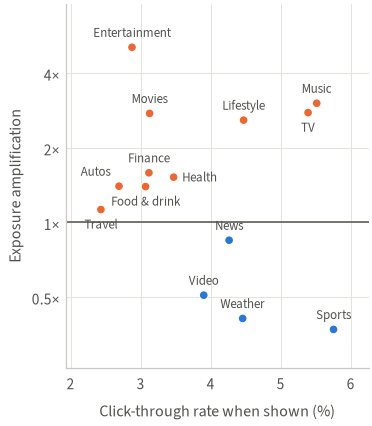

In [5]:
if have("category_metrics.csv"):
    d = main.copy()
    fig, ax = plt.subplots(figsize=(HALF, 4.3))
    colors = [S.ORANGE if a > 1 else S.BLUE for a in d["amplification"]]
    ax.scatter(d["ctr"] * 100, d["amplification"], color=colors, s=34, zorder=3, edgecolor="white", linewidth=0.8)
    ax.set_yscale("log"); ax.axhline(1, color=S.INK2, lw=1)
    ax.yaxis.set_major_locator(FixedLocator([0.25, 0.5, 1, 2, 4]))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}×")); ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlim(d["ctr"].min() * 100 - 0.5, d["ctr"].max() * 100 + 0.5)
    ax.set_ylim(d["amplification"].min() * 0.7, d["amplification"].max() * 1.5)
    S.place_labels(ax, d["ctr"] * 100, d["amplification"], [LBL(c) for c in d.index], fontsize=8.5)
    ax.set_xlabel("Click-through rate when shown (%)"); ax.set_ylabel("Exposure amplification")
    S.save(fig, FIG / "fig3_ctr_vs_amplification"); plt.show()

## 7. Figure 4 — Who gets the spotlight? (article concentration)

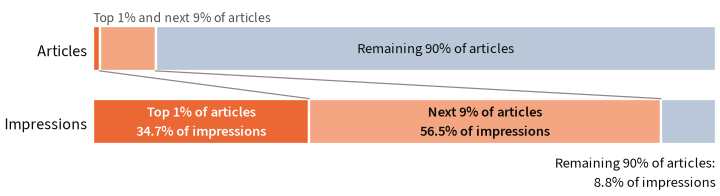

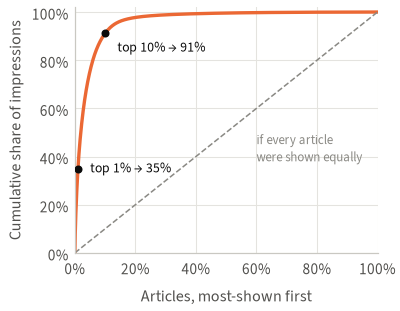

daily Gini range: 0.892–0.928 over 7 days


In [6]:
if have("concentration_metrics.csv", "article_exposure.csv"):
    conc = pd.read_csv(RES / "concentration_metrics.csv")
    m = conc.iloc[0]
    assert m["population"].startswith("exposed articles (train+dev)") and m["measure"] == "impressions"
    t1, t10 = m["top_1pct_share"], m["top_10pct_share"]
    segs_a = [0.01, 0.09, 0.90]; segs_i = [t1, t10 - t1, 1 - t10]
    labels = ["Top 1%", "Next 9%", "Remaining 90%"]
    colors = [S.ORANGE, "#f4a582", S.BASE]
    fig, ax = plt.subplots(figsize=(FULL, 2.2))
    for row, segs in [(1, segs_a), (0, segs_i)]:
        left = 0
        for s, c in zip(segs, colors):
            ax.barh(row, s, left=left, color=c, height=0.62, edgecolor="white", linewidth=1.5)
            left += s
    left_i = np.cumsum([0] + segs_i)
    left_a = np.cumsum([0] + segs_a)
    for k in range(2):
        ax.plot([left_a[k + 1], left_i[k + 1]], [0.69, 0.31], color=S.MUTED, lw=0.8)
    ax.text(left_i[0] + segs_i[0] / 2, 0, f"Top 1% of articles\n{pct(segs_i[0], 1)} of impressions", ha="center",
            va="center", fontsize=9.5, color="white", fontweight="semibold")
    ax.text(left_i[1] + segs_i[1] / 2, 0, f"Next 9% of articles\n{pct(segs_i[1], 1)} of impressions", ha="center",
            va="center", fontsize=9.5, color=S.INK, fontweight="semibold")
    ax.annotate(f"Remaining 90% of articles:\n{pct(segs_i[2], 1)} of impressions", (1.0, -0.31),
                xytext=(0, -6), textcoords="offset points", ha="right", va="top", fontsize=9.5, color=S.INK)
    ax.text(0, 1.42, "Top 1% and next 9% of articles", ha="left", va="center", fontsize=9, color=S.INK2)
    ax.text(left_a[2] + segs_a[2] / 2, 1, "Remaining 90% of articles", ha="center", va="center", fontsize=9.5, color=S.INK)
    ax.set_ylim(-0.95, 1.6)
    ax.set_yticks([1, 0], ["Articles", "Impressions"]); ax.tick_params(axis="y", labelsize=10.5, colors=S.INK)
    ax.set_xlim(0, 1); ax.set_xticks([]); ax.grid(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_visible(False)
    S.save(fig, FIG / "fig4_concentration_bars"); plt.show()

    art = pd.read_csv(RES / "article_exposure.csv")
    v = np.sort(art["impressions"].to_numpy())[::-1]
    share = np.cumsum(v) / v.sum(); frac = np.arange(1, v.size + 1) / v.size
    fig, ax = plt.subplots(figsize=(HALF, 2.9))
    ax.plot(frac * 100, share * 100, color=S.ORANGE, lw=2.2)
    ax.plot([0, 100], [0, 100], color=S.MUTED, lw=1, ls="--")
    ax.text(60, 38, "if every article\nwere shown equally", color=S.MUTED, fontsize=8.5, rotation=0)
    for f_ in (0.01, 0.10):
        k = int(np.ceil(f_ * v.size)); yv = share[k - 1] * 100
        ax.scatter(f_ * 100, yv, color=S.INK, s=18, zorder=4)
        ax.annotate(f"top {f_:.0%} → {yv:.0f}%", (f_ * 100, yv), xytext=(8, -12 if f_ > .05 else -2),
                    textcoords="offset points", fontsize=9, color=S.INK)
    ax.set_xlim(0, 100); ax.set_ylim(0, 102)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%")); ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_xlabel("Articles, most-shown first"); ax.set_ylabel("Cumulative share of impressions")
    S.save(fig, FIG / "fig4b_concentration_curve"); plt.show()

    daily = conc[conc["population"].str.contains("day")]
    print(f"daily Gini range: {daily['gini'].min():.3f}–{daily['gini'].max():.3f} over {len(daily)} days")

## 8. Figure 5 — Exposure and each user's own favourite category (Notebook 02)

In [7]:
if have("narrowing_alignment_by_quintile.csv"):
    q = pd.read_csv(RES / "narrowing_alignment_by_quintile.csv")
    fig, ax = plt.subplots(figsize=(HALF, 3.1))
    x = np.arange(len(q))
    ax.fill_between(x, q["null_low"] * 100, q["null_high"] * 100, color=S.GRID, lw=0)
    ax.plot(x, q["null_mean"] * 100, color=S.MUTED, lw=1.5, ls="--")
    ax.plot(x, q["observed_share_own_dom"] * 100, color=S.ORANGE, lw=2.2, marker="o", ms=5)
    ax.text(x[-1] + 0.12, q["observed_share_own_dom"].iat[-1] * 100, "observed", color=S.ORANGE, fontsize=9, va="center", fontweight="semibold")
    ax.text(x[-1] + 0.12, q["null_mean"].iat[-1] * 100, "if exposure\nignored history", color=S.MUTED, fontsize=8.5, va="center")
    ax.set_xticks(x, ["Broadest\nhistory", "", "", "", "Most\nconcentrated"])
    ax.set_xlim(-0.3, len(q) + 0.6)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_ylabel("Share of exposure in the user's\nfavourite (most-clicked) category")
    ax.set_xlabel("Users grouped by how concentrated\ntheir past clicks were (quintiles)")
    S.save(fig, FIG / "fig5_alignment"); plt.show()

SKIP — missing results: ['narrowing_alignment_by_quintile.csv']


In [8]:
if have("narrowing_alignment_by_category.csv"):
    c = pd.read_csv(RES / "narrowing_alignment_by_category.csv").sort_values("exposure_ratio")
    fig, ax = plt.subplots(figsize=(HALF, 3.1))
    y = np.arange(len(c))
    ax.hlines(y, c["exposure_share_other_users"] * 100, c["exposure_share_dominant_users"] * 100, color=S.GRID, lw=3)
    ax.scatter(c["exposure_share_other_users"] * 100, y, color=S.BASE, s=26, zorder=3, label="other users")
    ax.scatter(c["exposure_share_dominant_users"] * 100, y, color=S.ORANGE, s=26, zorder=3, label="users who mostly clicked it before")
    ax.set_yticks(y, [LBL(v) for v in c["category"]]); ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_xlabel("Share of logged exposure in that category")
    ax.legend(loc="lower left", bbox_to_anchor=(-0.02, 1.0), ncol=2, fontsize=8.5, handletextpad=0.2, columnspacing=1.0)
    ax.spines["left"].set_visible(False)
    S.save(fig, FIG / "fig5b_alignment_by_category"); plt.show()

SKIP — missing results: ['narrowing_alignment_by_category.csv']


In [9]:
if have("narrowing_hist2d.csv"):
    h = pd.read_csv(RES / "narrowing_hist2d.csv")
    fig, ax = plt.subplots(figsize=(HALF, 3.1))
    sc = ax.scatter((h["x_low"] + h["x_high"]) / 2, (h["y_low"] + h["y_high"]) / 2, s=np.sqrt(h["n_users"]) * 4,
                    color=S.BLUE, alpha=0.45, lw=0)
    lim = max(h["x_high"].max(), h["y_high"].max())
    ax.plot([1, lim], [1, lim], color=S.INK2, lw=1, ls="--")
    ax.text(lim * 0.97, lim * 0.93, "equal", color=S.INK2, fontsize=8.5, ha="right")
    ax.set_xlim(1, lim); ax.set_ylim(1, lim)
    ax.set_xlabel("Past clicks: effective number of categories"); ax.set_ylabel("Shown: effective number of categories")
    S.save(fig, FIG / "fig6_click_vs_exposure"); plt.show()

SKIP — missing results: ['narrowing_hist2d.csv']


In [10]:
if have("diversity_metrics.csv"):
    a = pd.read_csv(RES / "diversity_metrics.csv")
    fig, ax = plt.subplots(figsize=(HALF, 3.1))
    x = np.arange(len(a))
    ax.errorbar(x, 1 / a["exp_simpson_mean"], color=S.BLUE, marker="o", lw=2, ms=5)
    ax.set_xticks(x, a["activity_group"].str.replace(" ", "\n", n=1), fontsize=8.5)
    ax.set_ylabel("Shown: effective number of categories\n(1 ÷ mean Simpson concentration)")
    ax.set_xlabel("Behavioral activity group (past clicks)")
    ax.set_ylim(0, (1 / a["exp_simpson_mean"]).max() * 1.25)
    S.save(fig, FIG / "fig7_activity_groups"); plt.show()

SKIP — missing results: ['diversity_metrics.csv']


## 9. Figure 8 — Relevance vs. diversity (Notebook 03, simulated)

In [11]:
if have("recommender_frontier.csv", "recommender_metrics.csv"):
    fr = pd.read_csv(RES / "recommender_frontier.csv")
    sm = pd.read_csv(RES / "recommender_metrics.csv")
    rnd = sm[(sm["model"] == "random") & (sm["lam"] == 1.0)].iloc[0]
    colors = {"content": S.BLUE, "category": S.ORANGE, "popularity": S.AQUA}
    names = {"content": "Topic match (title words)", "category": "Favourite categories", "popularity": "Most clicked last week"}
    fig, ax = plt.subplots(figsize=(FULL * 0.62, 3.6))
    for bname, g in fr.groupby("base"):
        g = g.sort_values("lam", ascending=False)
        ax.plot(g["ndcg10"], g["distinct_categories"], color=colors[bname], lw=2, marker="o", ms=4.5, label=names[bname])
        r0 = g.iloc[0]
        ax.scatter(r0["ndcg10"], r0["distinct_categories"], s=70, facecolor="white", edgecolor=colors[bname], lw=2, zorder=4)
    ax.scatter(rnd["ndcg10"], rnd["distinct_categories"], marker="x", color=S.MUTED, s=40, zorder=4)
    ax.annotate("random order", (rnd["ndcg10"], rnd["distinct_categories"]), xytext=(6, -10), textcoords="offset points",
                fontsize=8.5, color=S.MUTED)
    ax.set_xlabel("Relevance → (nDCG@10 against real clicks)")
    ax.set_ylabel("Diversity → (categories in the top 10)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3, fontsize=8.5, handletextpad=0.3, columnspacing=1.0)
    ax.text(0.99, 0.02, "open circle = base ranking (λ = 1)\nthen λ = 0.9, 0.75, 0.5, 0.25, 0.1, 0", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8, color=S.INK2)
    S.save(fig, FIG / "fig8_frontier"); plt.show()

SKIP — missing results: ['recommender_frontier.csv', 'recommender_metrics.csv']


In [12]:
if have("recommender_metrics.csv"):
    sm = pd.read_csv(RES / "recommender_metrics.csv")
    bb = sm[(sm["lam"] == 1.0) & sm["model"].isin(["popularity", "content", "category"])].set_index("model")
    names = {"content": "Topic match", "category": "Favourite\ncategories", "popularity": "Most clicked\nlast week"}
    bb = bb.sort_values("amp_vs_history_mean")
    fig, ax = plt.subplots(figsize=(FULL * 0.36, 3.6))
    colors = [S.ORANGE if v > 1 else S.BLUE for v in bb["amp_vs_history_mean"]]
    ax.bar(np.arange(len(bb)), bb["amp_vs_history_mean"], color=colors, width=0.6)
    ax.axhline(1, color=S.INK2, lw=1)
    for i, v in enumerate(bb["amp_vs_history_mean"]):
        ax.text(i, v + 0.03, f"{v:.2f}×", ha="center", va="bottom", fontsize=9.5)
    ax.set_xticks(np.arange(len(bb)), [names[m] for m in bb.index], fontsize=8.5)
    ax.set_ylabel("Favourite-category share in top 10\n÷ share in past clicks")
    ax.grid(axis="x", visible=False); ax.set_ylim(0, bb["amp_vs_history_mean"].max() * 1.25)
    S.save(fig, FIG / "fig9_rec_amplification"); plt.show()

SKIP — missing results: ['recommender_metrics.csv']


## 10. Output inventory

In [13]:
for p in sorted(FIG.glob("*.png")):
    print(p.name)

fig1_slopegraph.png
fig2_amplification.png
fig3_ctr_vs_amplification.png
fig4_concentration_bars.png
fig4b_concentration_curve.png


## 11. Interpretation & limitations
Charts restate results from Notebooks 01–03; see those notebooks for interpretation, robustness and
limitations. Log scales are used only for ratios (amplification), where 0.5× and 2× must look symmetric
around 1×; every log axis is labelled with explicit "×" ticks.